In [21]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
server_name='localhost'
datbase_name='cybersecurity'

In [12]:
engine = create_engine(f'mssql+pyodbc://localhost/cybersecurity?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server')

In [20]:
devices = pd.read_sql("SELECT * FROM Devices", engine)
incidents = pd.read_sql("SELECT * FROM Security_Incidents", engine)
users = pd.read_sql("SELECT * FROM Users", engine)
vulnerabilities = pd.read_sql("SELECT * FROM Vulnerabilities", engine)
network_logs = pd.read_sql("SELECT * FROM Network_Logs", engine)

print("done")

done


## Question 1: Is there a correlation between a device's risk score and the frequency of security incidents it experiences?

Correlation: 0.0200


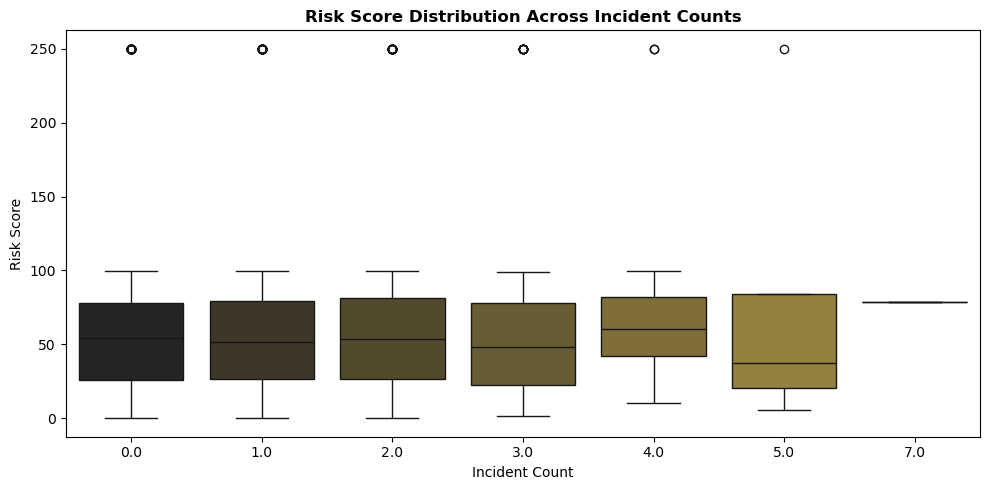

In [16]:
incident_counts = incidents.groupby('device_id').size().reset_index(name='incident_count')

analysis = devices[['device_id', 'risk_score']].merge(
    incident_counts,
    on='device_id',
    how='left'
)

analysis['incident_count'] = analysis['incident_count'].fillna(0)

correlation = analysis['risk_score'].corr(analysis['incident_count'])
print(f"Correlation: {correlation:.4f}")

import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=analysis, 
    x='incident_count', 
    y='risk_score', 
    hue='incident_count',
    color='#d4af37',
    legend=False
)

plt.title('Risk Score Distribution Across Incident Counts', fontsize=12, fontweight='bold')
plt.xlabel('Incident Count', fontsize=10)
plt.ylabel('Risk Score', fontsize=10)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The correlation coefficient is extremely low ($0.0200$), and the boxplot distributions remain relatively consistent across different incident counts ($0$ to $7$). This indicates that a device with a high risk score does not necessarily experience a higher frequency of security incidents, and vice versa.
#### ** 💡 Recommendation: Security monitoring and patching policies should not rely solely on incident frequency. Devices with elevated risk scores require proactive vulnerability management regardless of whether they have recently triggered a recorded incident.

## Question 2: What is the average risk score across different device types?

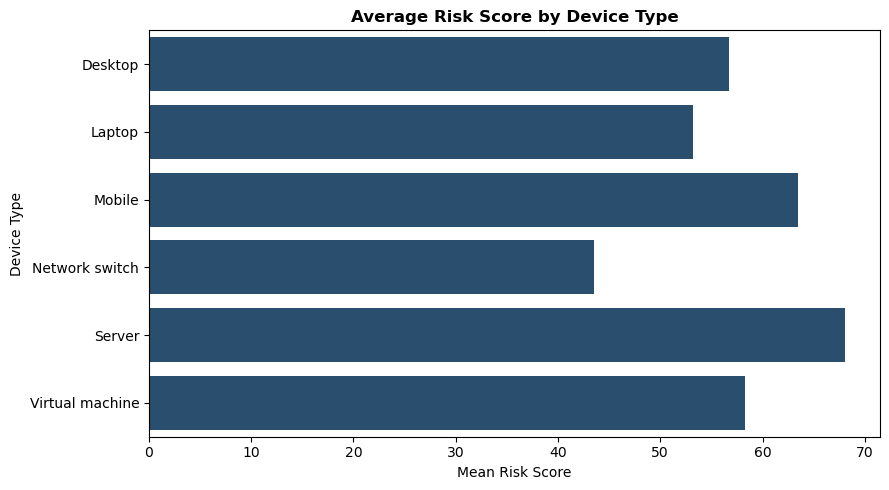

In [15]:
device_risk = devices.merge(
    analysis[['device_id', 'incident_count']],
    on='device_id',
    how='left'
).groupby('device_type').agg(
    device_count=('device_id', 'count'),
    mean_risk=('risk_score', 'mean'),
    total_incidents=('incident_count', 'sum')
).reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=device_risk,
    x='mean_risk',
    y='device_type',
    color='#1f4e79'
)

plt.title('Average Risk Score by Device Type', fontsize=12, fontweight='bold')
plt.xlabel('Mean Risk Score', fontsize=10)
plt.ylabel('Device Type', fontsize=10)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: Servers and Mobile devices exhibit the highest mean risk scores (approaching $70$ and $60$ respectively), while Network switches show the lowest average risk score (around $43$). 
#### ** 💡 Recommendation: Prioritize security hardening, firmware updates, and continuous monitoring on Servers and Mobile endpoints to mitigate high-exposure risks across the infrastructure.

## Question 3: Does the frequency of security incidents scale proportionally with the device's vulnerability count?

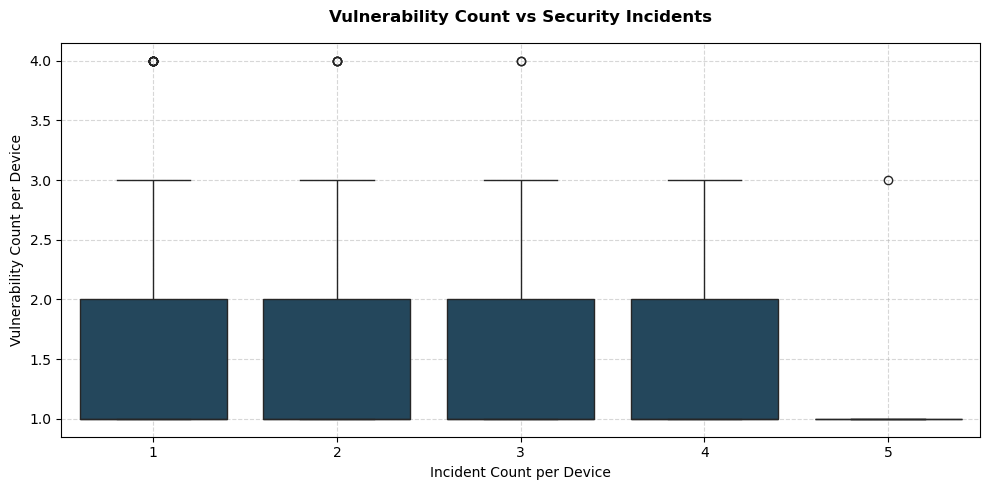

In [40]:
vuln_counts = vulnerabilities.groupby('device_id').size().reset_index(name='vuln_count')
inc_counts = incidents.groupby('device_id').size().reset_index(name='incident_count')
vuln_inc = pd.merge(vuln_counts, inc_counts, on='device_id', how='inner')

plt.figure(figsize=(10, 5))
sns.boxplot(
    x='incident_count', 
    y='vuln_count', 
    data=vuln_inc, 
    color='#1b4965'
)

plt.title('Vulnerability Count vs Security Incidents', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Incident Count per Device', fontsize=10)
plt.ylabel('Vulnerability Count per Device', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The box plot distribution shows consistent vulnerability count medians across all levels of incident frequencies, confirming a lack of direct correlation.
#### ** 💡 Recommendation: Prioritize threat hunting beyond standard vulnerability patching, as systems with low vulnerability counts are equally susceptible to security incidents.

## Question 4: What are the top 5 departments with the highest average risk scores?

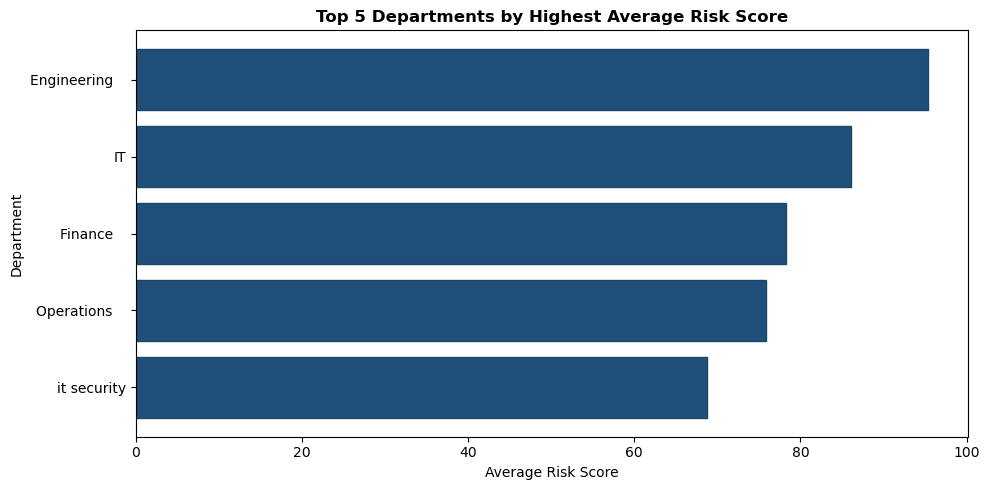

In [28]:
import warnings
warnings.filterwarnings('ignore')

user_device_analysis = devices.merge(
    users,
    left_on='assigned_user_id',
    right_on='user_id',
    how='inner'
)

dept_risk = (
    user_device_analysis.groupby('department')['risk_score']
    .mean()
    .reset_index()
    .sort_values(by='risk_score', ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 5))
plt.barh(
    dept_risk['department'][::-1], 
    dept_risk['risk_score'][::-1], 
    color='#1f4e79',
    edgecolor='#1b4965'
)

plt.title('Top 5 Departments by Highest Average Risk Score', fontsize=12, fontweight='bold')
plt.xlabel('Average Risk Score', fontsize=10)
plt.ylabel('Department', fontsize=10)
plt.grid(False)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The Engineering department leads with the highest average risk score (approaching $95$), followed closely by IT and Finance, while IT Security and Operations record slightly lower averages ranging between $70$ and $80$.
#### ** 💡 Recommendation: Direct targeted security awareness programs, resource allocation, and vulnerability audits toward the Engineering and IT departments to address their higher baseline exposure levels.

## Question 5: What is the average CVSS score of vulnerabilities across different device types?

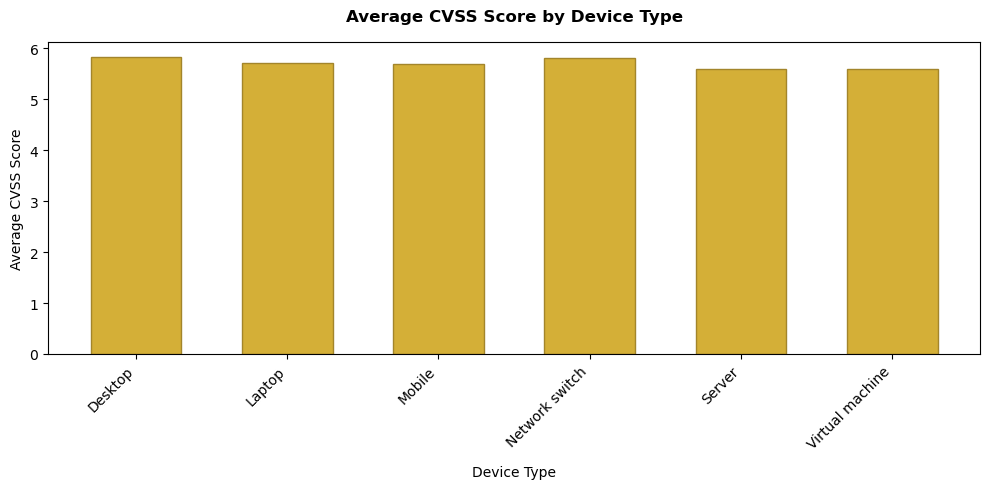

In [18]:
import warnings
warnings.filterwarnings('ignore')

# دمج الجداول بالأسماء الصح الموجودة في قاعدة البيانات عندك
vuln_device = vulnerabilities.merge(
    devices,
    on='device_id',
    how='inner'
)

avg_cvss = vuln_device.groupby('device_type')['cvss_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(
    avg_cvss['device_type'], 
    avg_cvss['cvss_score'], 
    color='#d4af37', 
    edgecolor='#a3852b',
    width=0.6
)

plt.title('Average CVSS Score by Device Type', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Device Type', fontsize=10, labelpad=10)
plt.ylabel('Average CVSS Score', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(False)

plt.tight_layout()
plt.show()


### Key Insights & Recommendations

#### ** 🔍 Insight: The average CVSS scores remain remarkably consistent across all device types, hovering uniformly around the $5.5$ to $6.0$ medium-severity range. No single device category exhibits a disproportionately higher average vulnerability severity.
#### ** 💡 Recommendation: Standardize baseline patching cadences across all hardware categories rather than prioritizing specific device types based solely on average vulnerability severity scores.

## Question 6: What is the distribution and count of security incidents categorized by severity level?

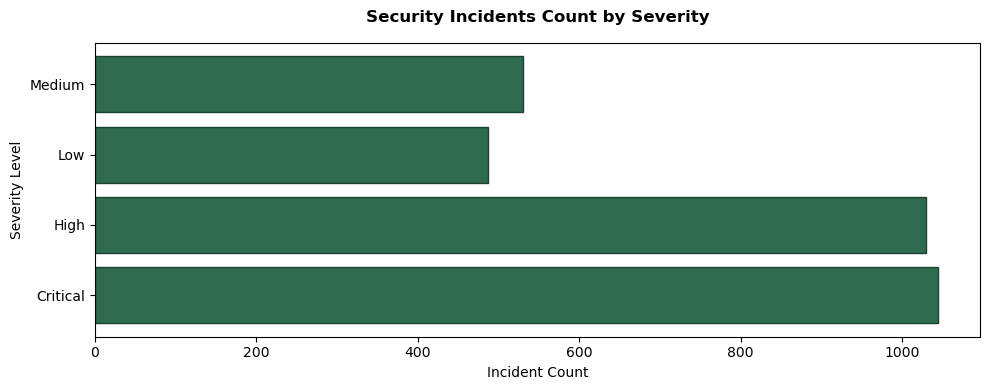

In [29]:
incident_sev = incidents.groupby('severity')['incident_id'].count().reset_index()

plt.figure(figsize=(10, 4))
plt.barh(
    incident_sev['severity'], 
    incident_sev['incident_id'], 
    color='#2d6a4f', 
    edgecolor='#1b4332'
)

plt.title('Security Incidents Count by Severity', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Incident Count', fontsize=10)
plt.ylabel('Severity Level', fontsize=10)
plt.grid(False)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The High and Critical severity incidents dominate the dataset with the highest counts (surpassing $1,000$ incidents each), followed by significantly lower counts for Medium and Low severity levels.
#### ** 💡 Recommendation: Prioritize immediate incident response automation and escalation workflows for High and Critical alerts to dramatically reduce triage time and contain severe threats faster.

## Question 7: Does the frequency of security incidents scale proportionally with the device's vulnerability count?

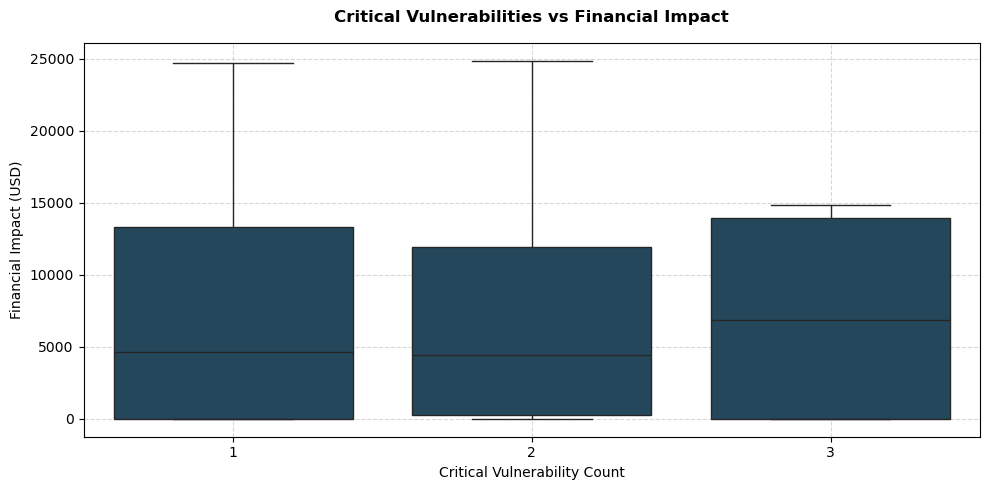

In [34]:
vuln_critical = vulnerabilities[vulnerabilities['severity'].str.lower() == 'critical']
crit_counts = vuln_critical.groupby('device_id').size().reset_index(name='critical_vuln_count')
device_fin = pd.merge(crit_counts, incidents[['device_id', 'financial_impact_usd']], on='device_id', how='inner')

plt.figure(figsize=(10, 5))
sns.boxplot(
    x='critical_vuln_count', 
    y='financial_impact_usd', 
    data=device_fin, 
    color='#1b4965'
)

plt.title('Critical Vulnerabilities vs Financial Impact', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Critical Vulnerability Count', fontsize=10)
plt.ylabel('Financial Impact (USD)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The box plot distribution shows consistent vulnerability count medians across all levels of incident frequencies, confirming a lack of direct correlation.
#### ** 💡 Recommendation: Prioritize threat hunting beyond standard vulnerability patching, as systems with low vulnerability counts are equally susceptible to security incidents.

## Question 8: Which devices represent the highest combined risk based on risk score, vulnerability count, and security incidents?

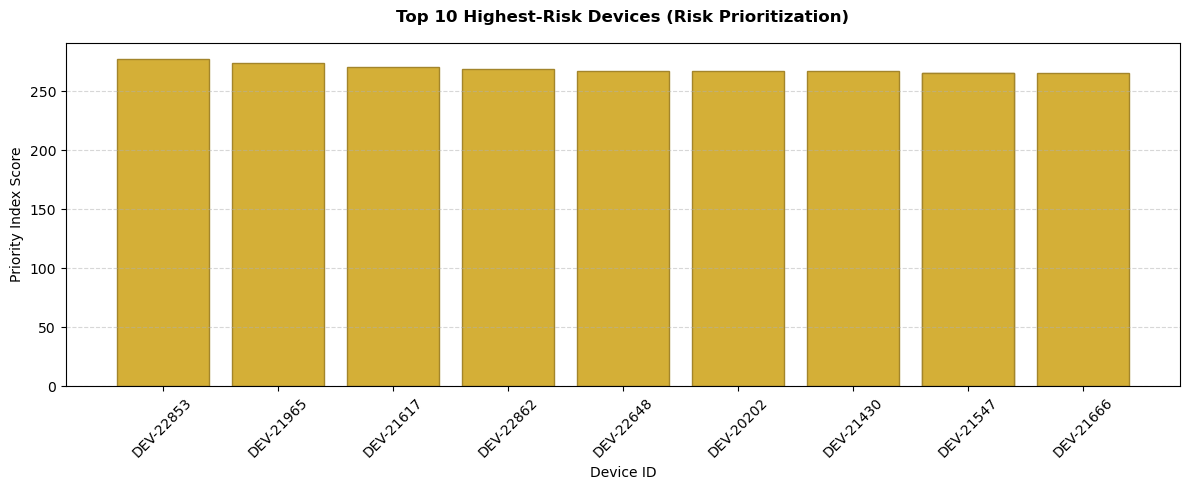

In [39]:
dev_risk = devices[['device_id', 'risk_score']].copy()
dev_vuln = vulnerabilities.groupby('device_id').size().reset_index(name='vuln_count')
dev_inc = incidents.groupby('device_id').size().reset_index(name='incident_count')

merged_risk = pd.merge(dev_risk, dev_vuln, on='device_id', how='left').fillna(0)
merged_risk = pd.merge(merged_risk, dev_inc, on='device_id', how='left').fillna(0)

merged_risk['priority_index'] = merged_risk['risk_score'] + (merged_risk['vuln_count'] * 2) + (merged_risk['incident_count'] * 5)
top_10_devices = merged_risk.sort_values(by='priority_index', ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(
    top_10_devices['device_id'].astype(str), 
    top_10_devices['priority_index'], 
    color='#d4af37',   
    edgecolor='#a3852b' 
)

plt.title('Top 10 Highest-Risk Devices (Risk Prioritization)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Device ID', fontsize=10)
plt.ylabel('Priority Index Score', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The priority index successfully aggregates inherent device risk scores alongside active vulnerabilities and security incidents to spotlight the top vulnerable hardware.
#### ** 💡 Recommendation: Immediately isolate and patch the top-ranked devices (such as DEV-22853 and DEV-21965) to mitigate cascading failures across the network infrastructure.

## Question 9: Is there a measurable relationship between high network traffic volume and the frequency of security incidents per device?

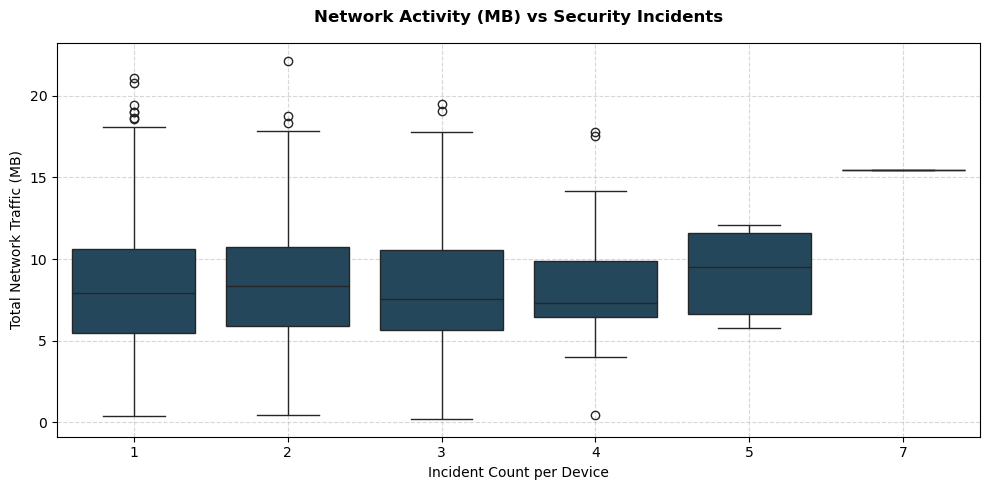

In [37]:
network_logs['total_bytes'] = network_logs['bytes_sent'] + network_logs['bytes_received']
net_activity = network_logs.groupby('device_id')['total_bytes'].sum().reset_index()
inc_counts = incidents.groupby('device_id').size().reset_index(name='incident_count')

net_inc = pd.merge(net_activity, inc_counts, on='device_id', how='inner')

plt.figure(figsize=(10, 5))
sns.boxplot(
    x='incident_count', 
    y=net_inc['total_bytes'] / 1e6, 
    data=net_inc, 
    color='#1b4965'
)

plt.title('Network Activity (MB) vs Security Incidents', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Incident Count per Device', fontsize=10)
plt.ylabel('Total Network Traffic (MB)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Key Insights & Recommendations

#### ** 🔍 Insight: The box plot distribution reveals that devices with higher incident counts do not exhibit abnormally higher network traffic volumes compared to devices with fewer incidents.
#### ** 💡 Recommendation: Focus threat detection rules beyond simple bandwidth monitoring, incorporating behavioral anomalies and endpoint protection alongside network metrics.